In [9]:
from datasets import load_dataset

# Load directly with datasets
ds = load_dataset("sruly/MCP-In-Practice", data_files="pulse_mcp_dataset.csv")

In [10]:
import pandas as pd

In [12]:
df1 = ds["train"].to_pandas()

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  2888 non-null   int64  
 1   page_num                    2888 non-null   int64  
 2   page_idx                    2888 non-null   int64  
 3   slug                        2888 non-null   object 
 4   rank                        2888 non-null   int64  
 5   href                        2888 non-null   object 
 6   title                       2888 non-null   object 
 7   author                      2888 non-null   object 
 8   description                 2888 non-null   object 
 9   release_date                2888 non-null   object 
 10  github_url                  2888 non-null   object 
 11  primary_category            2888 non-null   object 
 12  category_rationale          2888 non-null   object 
 13  secondary_categories        2888 

In [14]:
print(df1.isnull().sum())

Unnamed: 0                       0
page_num                         0
page_idx                         0
slug                             0
rank                             0
href                             0
title                            0
author                           0
description                      0
release_date                     0
github_url                       0
primary_category                 0
category_rationale               0
secondary_categories             0
interaction_type                 0
interaction_type_rationale       0
username                         0
repo                             0
star_list                        0
error                         2888
computed_star_count              0
dtype: int64


In [15]:
print(df1["primary_category"].unique())

['Information Retrieval & Search' 'Tech Platform Integrations'
 'Project Management' 'Software Engineering' 'Computer and Web Automation'
 'Data Analytics' 'Cloud and Infrastructure' 'Cybersecurity and Auth'
 'Creativity and Recreational Use' 'LLM Communication' 'Finance' 'Other']


In [17]:
df1["release_date"] = pd.to_datetime(df1["release_date"], errors="coerce")

In [20]:
server_count = df1["primary_category"].value_counts()
server_count

primary_category
Tech Platform Integrations         800
Information Retrieval & Search     555
Software Engineering               332
Computer and Web Automation        267
Cloud and Infrastructure           212
Data Analytics                     162
LLM Communication                  153
Finance                            136
Project Management                 101
Creativity and Recreational Use     89
Cybersecurity and Auth              80
Other                                1
Name: count, dtype: int64

<Axes: title={'center': 'Servers per Primary Category'}, xlabel='primary_category'>

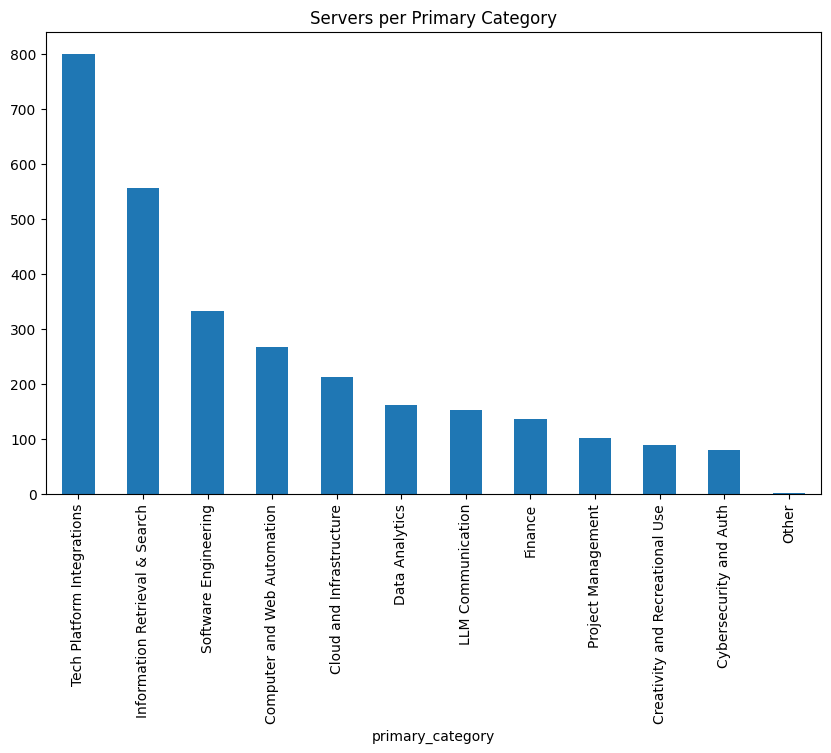

In [26]:
df1["primary_category"].value_counts().plot.bar(figsize=(10,6), title="Servers per Primary Category")

Text(0, 0.5, 'Number of Servers')

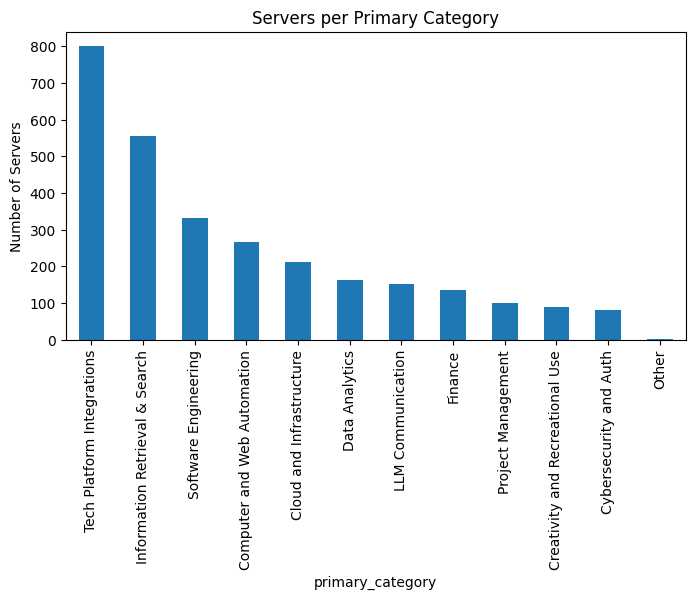

In [42]:
ax = df1["primary_category"].value_counts().plot.bar(
    figsize=(8,4), 
    title="Servers per Primary Category"
)

ax.set_ylabel("Number of Servers")

In [43]:
# Save as PNG
ax.figure.savefig("MCP Servers per Category.png", dpi=300, bbox_inches="tight")

In [31]:
df1["release_date"] = pd.to_datetime(df1["release_date"], errors="coerce")

In [32]:
servers_per_day = df1.groupby("release_date").size()

In [33]:
servers_per_month = df1.groupby(df1["release_date"].dt.to_period("M")).size()

Text(0, 0.5, 'Number of Servers')

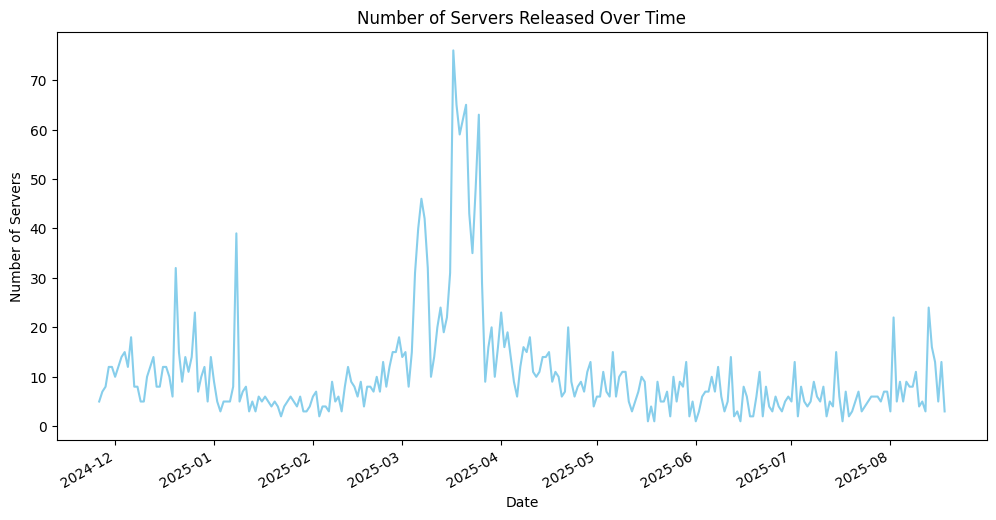

In [34]:
ax = servers_per_day.plot(
    figsize=(12,6),
    title="Number of Servers Released Over Time",
    color="skyblue"
)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Servers")

Text(0, 0.5, 'Number of Servers')

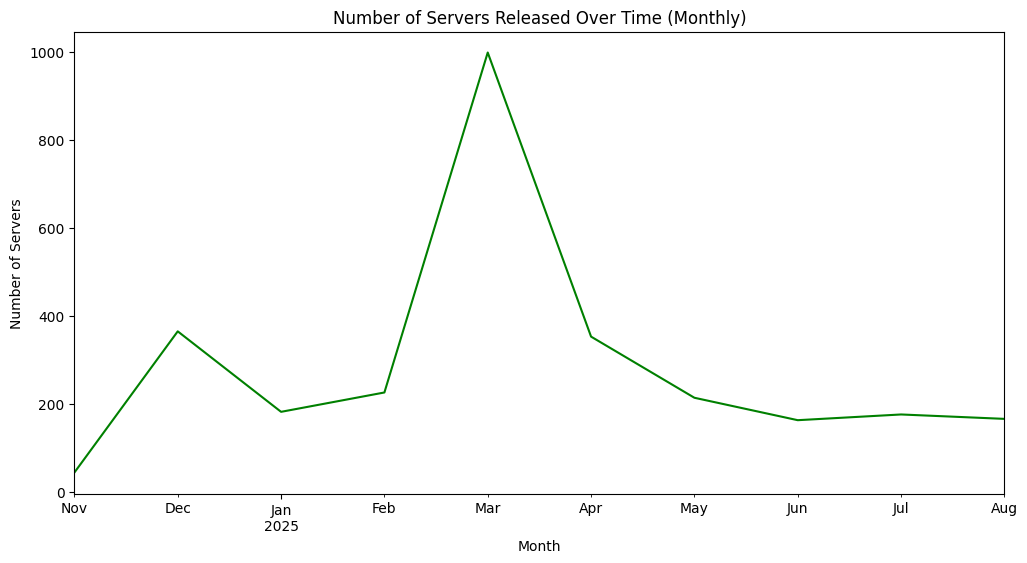

In [35]:
ax = servers_per_month.plot(
    figsize=(12,6),
    title="Number of Servers Released Over Time (Monthly)",
    color="green"
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Servers")

Text(0, 0.5, 'Servers Created')

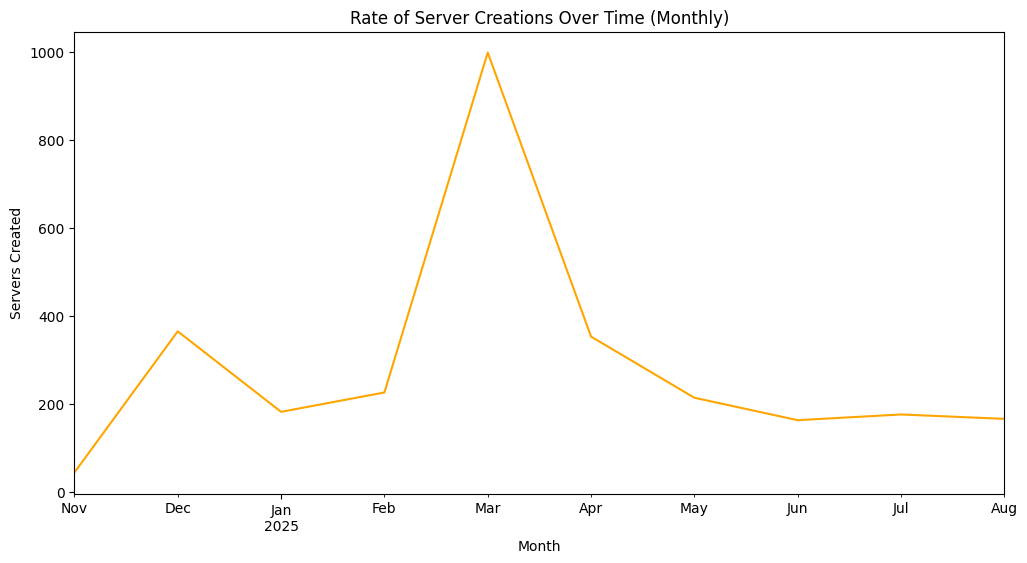

In [36]:
# Make sure release_date is datetime
df1["release_date"] = pd.to_datetime(df1["release_date"], errors="coerce")

# Group by month
servers_per_month = df1.groupby(df1["release_date"].dt.to_period("M")).size()

# Plot
ax = servers_per_month.plot(
    figsize=(12,6),
    title="Rate of Server Creations Over Time (Monthly)",
    color="orange"
)
ax.set_xlabel("Month")
ax.set_ylabel("Servers Created")

Text(0, 0.5, 'New Servers Added')

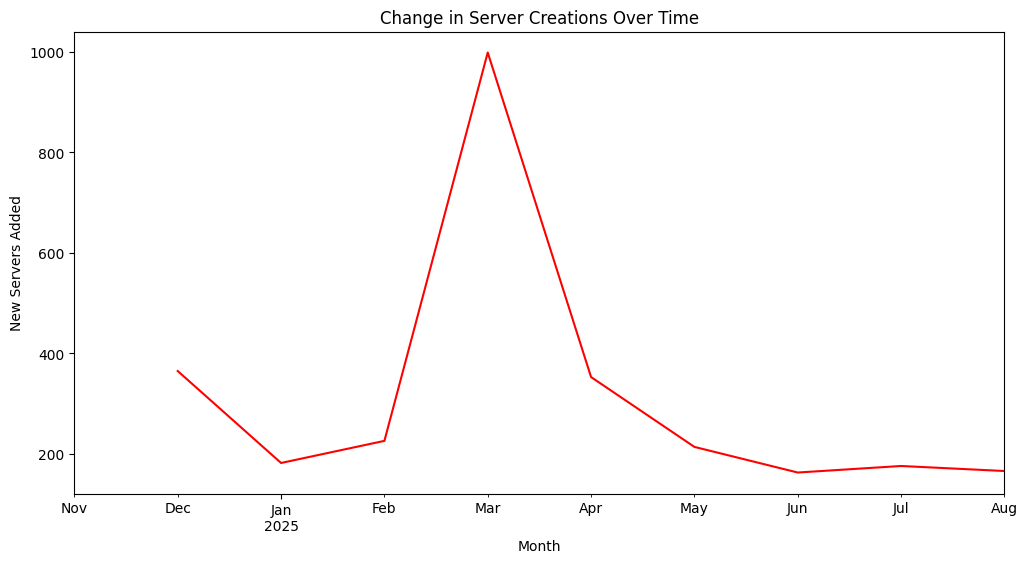

In [37]:
# Cumulative total
cumulative_servers = servers_per_month.cumsum()

# Rate of change (first derivative)
rate_of_change = cumulative_servers.diff()

ax = rate_of_change.plot(
    figsize=(12,6),
    title="Change in Server Creations Over Time",
    color="red"
)
ax.set_xlabel("Month")
ax.set_ylabel("New Servers Added")

In [38]:
df1["release_date"] = pd.to_datetime(df1["release_date"], errors="coerce")

df_tech = df1[df1["primary_category"] == "Tech Platform Integrations"]

In [39]:
servers_per_month = df_tech.groupby(df_tech["release_date"].dt.to_period("M")).size()

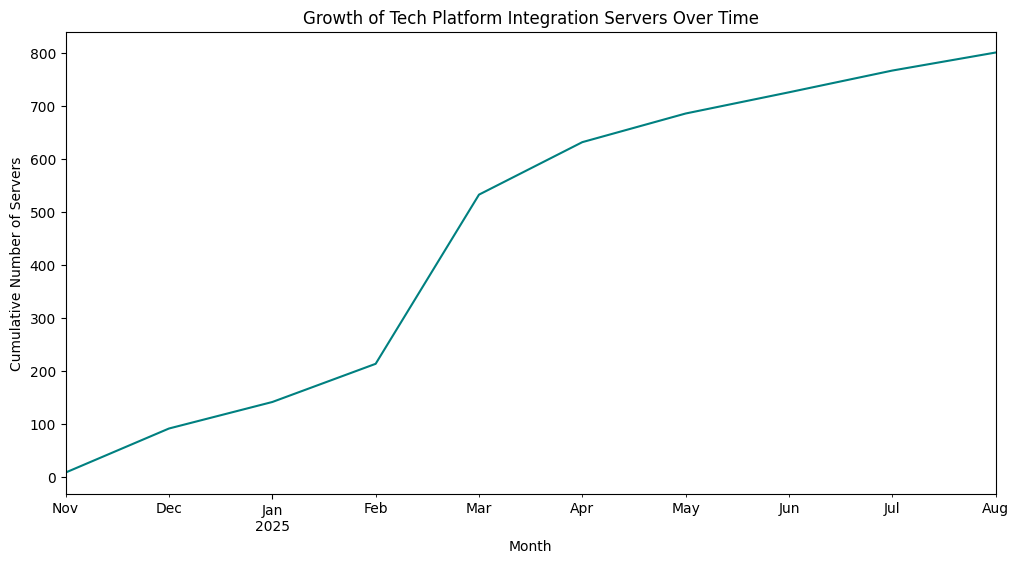

In [41]:
cumulative_servers = servers_per_month.cumsum()

ax = cumulative_servers.plot(
    figsize=(12,6),
    title="Growth of Tech Platform Integration Servers Over Time",
    color="teal"
)

ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Number of Servers")

# Save the plot to a PNG file
ax.figure.savefig("tech_platform_integrations_growth.png", dpi=300, bbox_inches="tight")